In [55]:
#here we are going to create a simple iterative workflow 
#here we write an x post and optimize it until its get approved 


In [56]:
from dotenv import load_dotenv 
load_dotenv()

True

In [57]:

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END 
from pydantic import BaseModel,Field 
from typing import TypedDict ,Literal,Annotated,operator
from langchain_core.messages import HumanMessage,SystemMessage
generator_llm = ChatGroq(model='Llama3-70b-8192')
evaluator_llm=ChatGroq(model='Llama-3.3-70b-Versatile')
optimizer_llm=ChatGroq(model='Llama-3.3-70b-Versatile') 


In [58]:
#we have to make our evaluator_llm with the structured_output 
#which have 2 possible values approved and needs_improvment 
class Evaluation_schema(BaseModel): 
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation of given tweet.")
    feedback: str = Field(..., description="feedback description for the tweet.")
    
structured_evaluator_llm=evaluator_llm.with_structured_output(Evaluation_schema) 

In [59]:
#lets firstly define our state 



class Tweet_state(TypedDict): 
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int
    
    
    #lets also maintain the history of the feedback and changes in the tweet 
    feedback_historty: Annotated[list[str],operator.add]
    tweet_history: Annotated[list[str],operator.add]
    #this is our state 

In [60]:
#lets make graph for our system 
graph=StateGraph(Tweet_state) 


In [61]:
def generate_tweet(state: Tweet_state):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response,'tweet_history': [response]}

In [62]:
def evaluate_tweet(state: Tweet_state):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback,'feedback_history':[response.feedback]}

In [63]:
def optimize_tweet(state: Tweet_state):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [64]:

#logic for the conditional node 
#here our max iteration are 5 because we doesn't llm to stuck in the time taking loop 
def check_evaluation(state: Tweet_state)-> Literal['approved','needs_improvement']:
    

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [65]:
#lets add nodes  
graph.add_node('generate',generate_tweet)
graph.add_node('evaluator',evaluate_tweet) 
graph.add_node('optimizer',optimize_tweet) 

graph.add_edge(START,'generate') 
graph.add_edge('generate','evaluator') 

#now here we have to add teh conditional edge 
graph.add_conditional_edges('evaluator',check_evaluation,{'approved':END,'needs_improvement':'optimizer'}) 

graph.add_edge('optimizer','evaluator' )
 


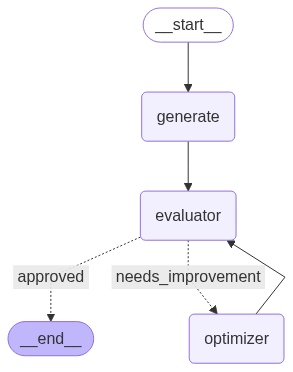

In [66]:
workflow=graph.compile() 
workflow
#here we are seeing the dotted line with the node to another node this is because of our dict mapping 
#inside of the add_conditional_edges()  

In [67]:
#lets see how it is working 
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [68]:
result

{'topic': 'srhberhb',
 'tweet': '"Just spent 10 minutes trying to autocorrect \'srhberhb\' and now I\'m wondering if I\'m the one who needs to get my life together "',
 'evaluation': 'approved',
 'feedback': "This tweet is a gem, showcasing originality by highlighting a ridiculously relatable struggle with autocorrect. The humor is spot on, as the self-deprecating humor and unexpected twist at the end genuinely evoke a chuckle. The punchiness is excellent, with a short and sharp delivery that's scroll-stopping. The virality potential is high, as people can easily retweet or share this laughable moment. The format is also well-executed, being under 280 characters and avoiding common pitfalls like question-answer format or traditional setup-punchline jokes. Overall, this tweet is a masterclass in crafting a humorous and engaging post.",
 'iteration': 1,
 'max_iteration': 5,
 'feedback_historty': [],
 'tweet_history': ['"Just spent 10 minutes trying to autocorrect \'srhberhb\' and now I\'